/Users/marcelaovandotellez/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


AUC for GM vs Functional: 0.12574134503114792
AUC for WM vs Functional: 0.020148809280578987
AUC for GM vs Structural: 0.023284168092306542
AUC for WM vs Structural: 0.15252936972269926

GM vs Functional vs WM vs Functional
Mean difference: 0.1039
95% CI: [0.0624, 0.1445]

GM vs Structural vs WM vs Structural
Mean difference: 0.1236
95% CI: [0.0773, 0.1719]

WM vs Structural vs WM vs Functional
Mean difference: 0.1290
95% CI: [0.0765, 0.1788]

GM vs Structural vs GM vs Functional
Mean difference: 0.0983
95% CI: [0.0641, 0.1331]


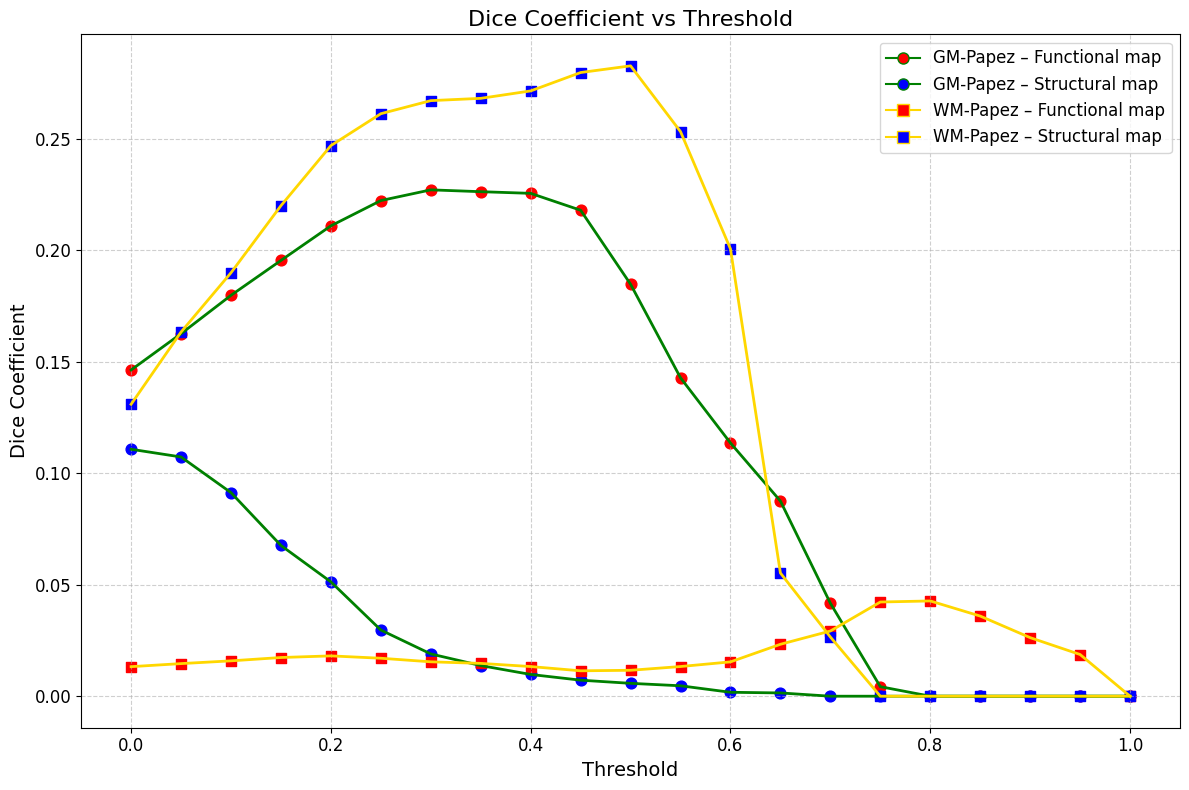

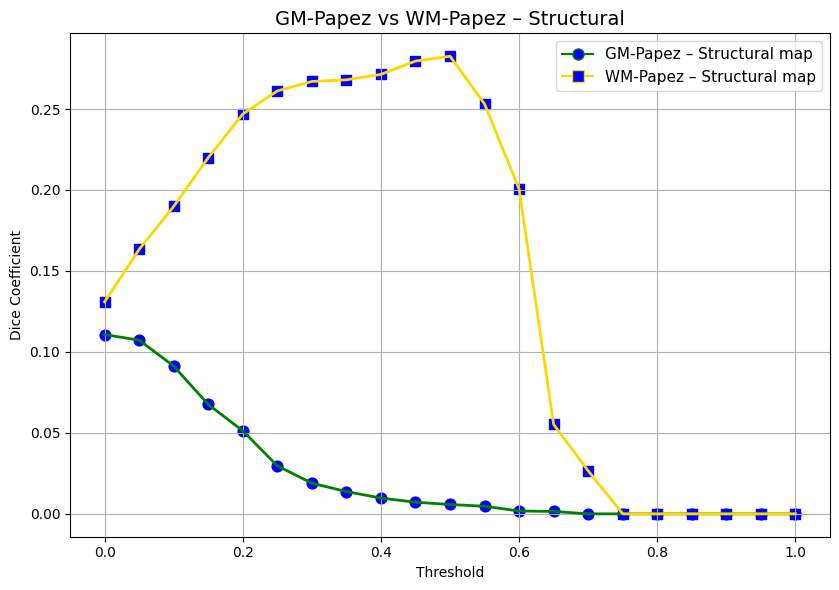

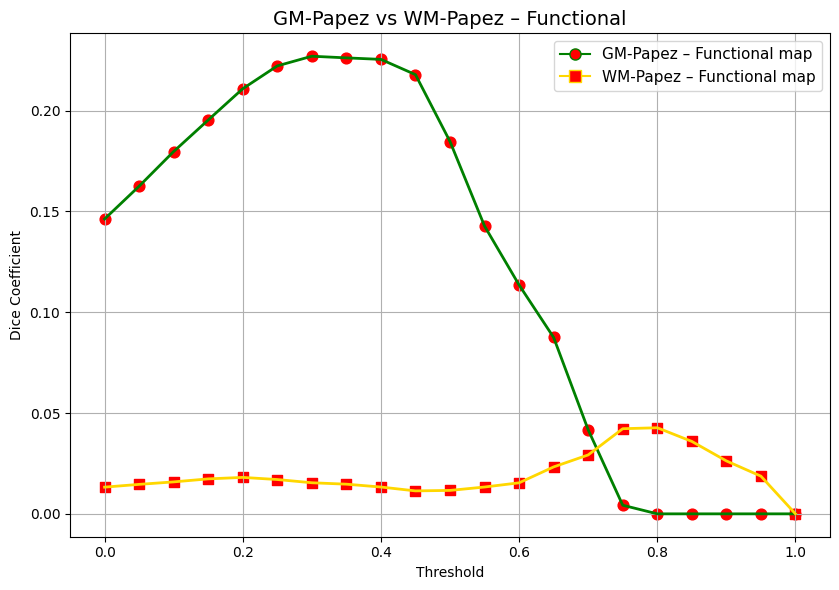

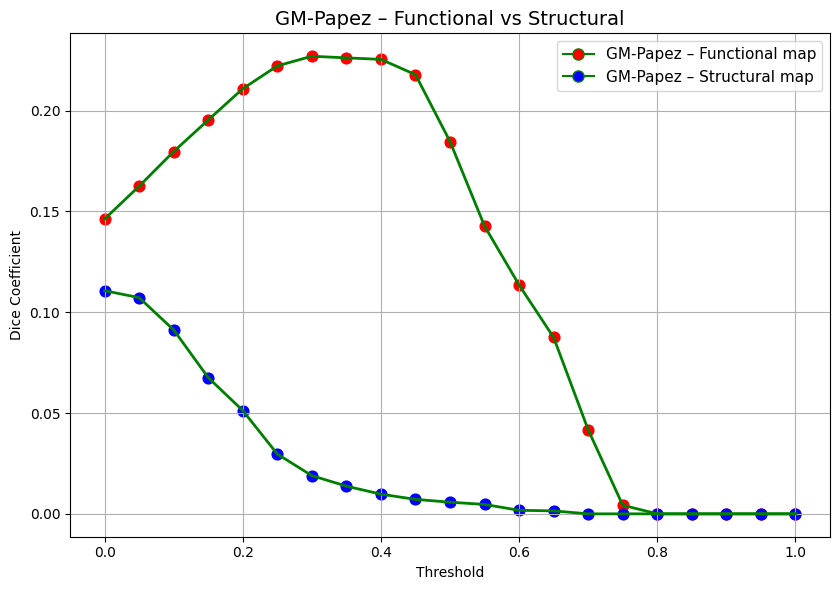

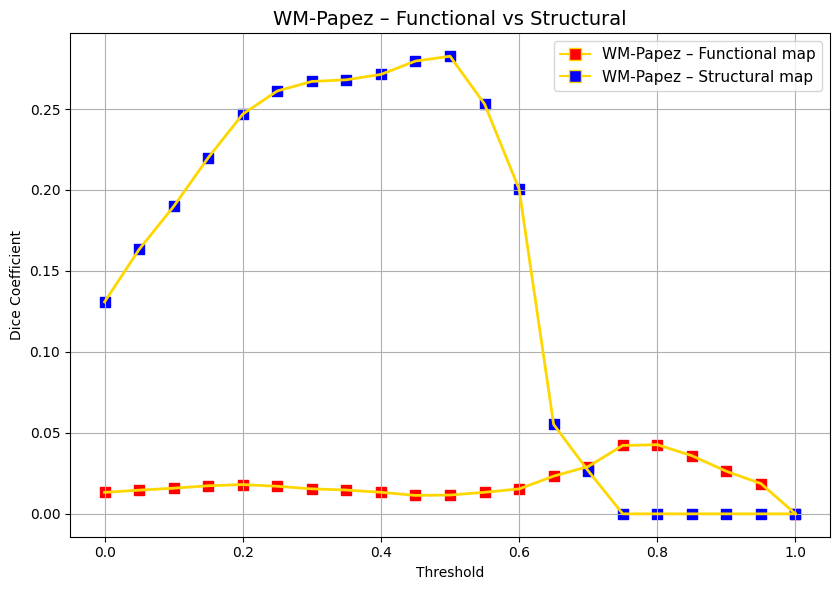

In [1]:

import numpy as np
from sklearn.metrics import auc
import nibabel as nib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# Function to compute bootstrap confidence intervals
def bootstrap(data1, data2, n_bootstrap=10000, alpha=0.05):
    boot_diffs = []
    for _ in range(n_bootstrap):
        resample_indices = np.random.choice(len(data1), len(data1), replace=True)
        resampled_data1 = data1[resample_indices]
        resampled_data2 = data2[resample_indices]
        diff = np.mean(resampled_data1 - resampled_data2)
        boot_diffs.append(diff)
    lower = np.percentile(boot_diffs, 100 * (alpha / 2))
    upper = np.percentile(boot_diffs, 100 * (1 - alpha / 2))
    return np.mean(boot_diffs), lower, upper

# Function to compute Dice coefficient
def dice_coefficient(mask1, mask2):
    intersection = np.sum(mask1 * mask2)
    dice = (2. * intersection) / (np.sum(mask1) + np.sum(mask2))
    return dice

# Load binary GM map (Limbic circuit) for gray matter
gm_map_img = nib.load('GM_combined_final.nii.gz')
gm_map_data = gm_map_img.get_fdata()

# Load binary WM map (Limbic circuit) for white matter
wm_map_img = nib.load('WM_combined_final.nii.gz')
wm_map_data = wm_map_img.get_fdata()

# Load functional and structural data-driven maps (from memory patients)
functional_map_img = nib.load('t_pos_significantFUNC_MNImasked.nii.gz')
functional_map_data = functional_map_img.get_fdata()

structural_map_img = nib.load('t_pos_significantANAT_MNImasked.nii.gz')
structural_map_data = structural_map_img.get_fdata()


# Replace NaN values with 0 in functional and structural maps
functional_map_data = np.nan_to_num(functional_map_data, nan=0)
structural_map_data = np.nan_to_num(structural_map_data, nan=0)

# Define known non-zero minimum t-values for normalization
functional_min = 4.62
structural_min = 5.87

# Get max values from the data
functional_max = np.max(functional_map_data)
structural_max = np.max(structural_map_data)

# Normalize each map based on its own min and max
functional_map_data_norm = (functional_map_data - functional_min) / (functional_max - functional_min)
functional_map_data_norm[functional_map_data < functional_min] = 0  # Zero out values below min

structural_map_data_norm = (structural_map_data - structural_min) / (structural_max - structural_min)
structural_map_data_norm[structural_map_data < structural_min] = 0  # Zero out values below min

# Define thresholds for binarization (from 0 to 1, step=0.05)
#thresholds = np.arange(0, max_value, 0.05)
# Define thresholds from 0 to 1 (normalized scale)
thresholds = np.arange(0, 1.05, 0.05)

gm_func_dice = []
wm_func_dice = []
gm_struct_dice = []
wm_struct_dice = []

for thresh in thresholds:
    # Binarize functional and structural maps at the current threshold
    functional_binary = (functional_map_data_norm > thresh).astype(int)
    structural_binary = (structural_map_data_norm > thresh).astype(int)
    
    # Compute Dice coefficients
    gm_func_dice.append(dice_coefficient(gm_map_data, functional_binary))
    wm_func_dice.append(dice_coefficient(wm_map_data, functional_binary))
    gm_struct_dice.append(dice_coefficient(gm_map_data, structural_binary))
    wm_struct_dice.append(dice_coefficient(wm_map_data, structural_binary))

# Convert lists to numpy arrays
gm_func_dice = np.array(gm_func_dice)
wm_func_dice = np.array(wm_func_dice)
gm_struct_dice = np.array(gm_struct_dice)
wm_struct_dice = np.array(wm_struct_dice)

# Compute AUC for each pair
auc_gm_func = auc(thresholds, gm_func_dice)
auc_wm_func = auc(thresholds, wm_func_dice)
auc_gm_struct = auc(thresholds, gm_struct_dice)
auc_wm_struct = auc(thresholds, wm_struct_dice)

# Print AUC values
print(f"AUC for GM vs Functional: {auc_gm_func}")
print(f"AUC for WM vs Functional: {auc_wm_func}")
print(f"AUC for GM vs Structural: {auc_gm_struct}")
print(f"AUC for WM vs Structural: {auc_wm_struct}")

# Bootstrap analysis to compare curves
comparisons = {
    "GM vs Functional vs WM vs Functional": (gm_func_dice, wm_func_dice),
    "GM vs Structural vs WM vs Structural": (wm_struct_dice, gm_struct_dice),
    "WM vs Structural vs WM vs Functional": (wm_struct_dice, wm_func_dice),
    "GM vs Structural vs GM vs Functional": (gm_func_dice, gm_struct_dice),
}

for label, (data1, data2) in comparisons.items():
    mean_diff, lower_ci, upper_ci = bootstrap(data1, data2)
    print(f"\n{label}")
    print(f"Mean difference: {mean_diff:.4f}")
    print(f"95% CI: [{lower_ci:.4f}, {upper_ci:.4f}]")


plt.figure(figsize=(12, 8))

# GM – Functional : Green line, Red markers
plt.plot(thresholds, gm_func_dice, label='GM-Papez – Functional map', color='green', linewidth=2)
plt.scatter(thresholds, gm_func_dice, color='red', marker='o', s=60)

# GM – Structural : Green line, Blue markers
plt.plot(thresholds, gm_struct_dice, label='GM-Papez – Structural map', color='green', linewidth=2)
plt.scatter(thresholds, gm_struct_dice, color='blue', marker='o', s=60)

# WM – Functional : Yellow line, Red markers
plt.plot(thresholds, wm_func_dice, label='WM-Papez – Functional map', color='gold', linewidth=2)
plt.scatter(thresholds, wm_func_dice, color='red', marker='s', s=60)

# WM – Structural : Yellow line, Blue markers
plt.plot(thresholds, wm_struct_dice, label='WM-Papez – Structural map', color='gold', linewidth=2)
plt.scatter(thresholds, wm_struct_dice, color='blue', marker='s', s=60)

# Plot settings
plt.xlabel('Threshold', fontsize=14)
plt.ylabel('Dice Coefficient', fontsize=14)
plt.title('Dice Coefficient vs Threshold', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
#plt.legend(fontsize=12, frameon=True)
plt.tight_layout()

# Custom legend elements
legend_elements = [
    Line2D([0], [0], color='green', marker='o', linestyle='-', markersize=8, label='GM-Papez – Functional map', markerfacecolor='red'),
    Line2D([0], [0], color='green', marker='o', linestyle='-', markersize=8, label='GM-Papez – Structural map', markerfacecolor='blue'),
    Line2D([0], [0], color='gold', marker='s', linestyle='-', markersize=8, label='WM-Papez – Functional map', markerfacecolor='red'),
    Line2D([0], [0], color='gold', marker='s', linestyle='-', markersize=8, label='WM-Papez – Structural map', markerfacecolor='blue'),
]

plt.legend(handles=legend_elements, fontsize=12, frameon=True)


# Define reusable legend elements
legend_gm_func = Line2D([0], [0], color='green', marker='o', linestyle='-', markersize=8, label='GM-Papez – Functional map', markerfacecolor='red')
legend_wm_func = Line2D([0], [0], color='gold', marker='s', linestyle='-', markersize=8, label='WM-Papez – Functional map', markerfacecolor='red')
legend_gm_struct = Line2D([0], [0], color='green', marker='o', linestyle='-', markersize=8, label='GM-Papez – Structural map', markerfacecolor='blue')
legend_wm_struct = Line2D([0], [0], color='gold', marker='s', linestyle='-', markersize=8, label='WM-Papez – Structural map', markerfacecolor='blue')

# Individual plots for each pair
# Plot 1: GM Structural vs WM Structural
plt.figure(figsize=(10, 6))
plt.plot(thresholds, gm_struct_dice, label='GM-Papez – Structural map', color='green', linewidth=2)
plt.scatter(thresholds, gm_struct_dice, color='blue', marker='o', s=60)
plt.plot(thresholds, wm_struct_dice, label='WM-Papez – Structural map', color='gold', linewidth=2)
plt.scatter(thresholds, wm_struct_dice, color='blue', marker='s', s=60)
plt.title('GM-Papez vs WM-Papez – Structural', fontsize=14)
plt.xlabel('Threshold')
plt.ylabel('Dice Coefficient')
plt.legend(
    handles=[legend_gm_struct, legend_wm_struct],
    loc='upper right',
    bbox_to_anchor=(1.0, 1.0),
    fontsize=11,
    frameon=True
)
#plt.legend(handles=[legend_gm_struct, legend_wm_struct], fontsize=12, frameon=True)
plt.grid(True)
plt.tight_layout(rect=[0, 0, 0.85, 1])

# Plot 2: GM Functional vs WM Functional
plt.figure(figsize=(10, 6))
plt.plot(thresholds, gm_func_dice, label='GM-Papez – Functional map', color='green', linewidth=2)
plt.scatter(thresholds, gm_func_dice, color='red', marker='o', s=60)
plt.plot(thresholds, wm_func_dice, label='WM-Papez – Functional map', color='gold', linewidth=2)
plt.scatter(thresholds, wm_func_dice, color='red', marker='s', s=60)
plt.title('GM-Papez vs WM-Papez – Functional', fontsize=14)
plt.xlabel('Threshold')
plt.ylabel('Dice Coefficient')
plt.legend(
    handles=[legend_gm_func, legend_wm_func],
    loc='upper right',
    bbox_to_anchor=(1.0, 1.0),
    fontsize=11,
    frameon=True
)
#plt.legend(handles=[legend_gm_func, legend_wm_func], fontsize=12, frameon=True)
plt.grid(True)
plt.tight_layout(rect=[0, 0, 0.85, 1])

# Plot 3: GM Functional vs GM Structural
plt.figure(figsize=(10, 6))
plt.plot(thresholds, gm_func_dice, label='GM-Papez – Functional map', color='green', linewidth=2)
plt.scatter(thresholds, gm_func_dice, color='red', marker='o', s=60)
plt.plot(thresholds, gm_struct_dice, label='GM-Papez – Structural map', color='green', linewidth=2)
plt.scatter(thresholds, gm_struct_dice, color='blue', marker='o', s=60)
plt.title('GM-Papez – Functional vs Structural', fontsize=14)
plt.xlabel('Threshold')
plt.ylabel('Dice Coefficient')
plt.legend(
    handles=[legend_gm_func, legend_gm_struct],
    loc='upper right',
    bbox_to_anchor=(1.0, 1.0),
    fontsize=11,
    frameon=True
)
#plt.legend(handles=[legend_gm_func, legend_gm_struct], fontsize=12, frameon=True)
plt.grid(True)
plt.tight_layout(rect=[0, 0, 0.85, 1])

# Plot 4: WM Functional vs WM Structural
plt.figure(figsize=(10, 6))
plt.plot(thresholds, wm_func_dice, label='WM-Papez – Functional map', color='gold', linewidth=2)
plt.scatter(thresholds, wm_func_dice, color='red', marker='s', s=60)
plt.plot(thresholds, wm_struct_dice, label='WM-Papez – Structural map', color='gold', linewidth=2)
plt.scatter(thresholds, wm_struct_dice, color='blue', marker='s', s=60)
plt.title('WM-Papez – Functional vs Structural', fontsize=14)
plt.xlabel('Threshold')
plt.ylabel('Dice Coefficient')
# Custom legend (defined earlier)
plt.legend(
    handles=[legend_wm_func, legend_wm_struct],
    loc='upper right',
    bbox_to_anchor=(1.0, 1.0),
    fontsize=11,
    frameon=True
)
#plt.legend(handles=[legend_wm_func, legend_wm_struct], fontsize=12, frameon=True)
plt.grid(True)
plt.tight_layout(rect=[0, 0, 0.85, 1])


plt.show()
